# Visualisasi Eksperimen A/B Testing: Kualitas Dataset & Latensi Backend
Notebook ini digunakan untuk memvisualisasikan data mentah hasil pengujian 50 *test cases* (`ab_testing_results.csv`) untuk membandingkan performa antara Varian A (Dataset OLD) dan Varian B (Dataset ULTIMATE).

## Import Libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [8]:
# Baca data hasil running
df = pd.read_csv("output_ab/ab_testing_results.csv")
df.head()

,case_id,query,noise_variant_a,noise_variant_b,latency_variant_a,latency_variant_b
0,1,"html, css, javascript, react, sass",4,1,126.643972,111.514309
1,2,"java, mysql, rest api, javascript",5,0,128.123080,113.449768
2,3,"golang, microservices, redis, postgresql",5,0,192.896348,136.394463
3,4,"typescript, node.js, express.js, react, mongodb",3,1,169.644774,104.803941
4,5,"kotlin, android studio, jetpack compose, firebase",6,0,195.111271,132.835168


In [9]:
print("=== METRIK RATA-RATA UNTUK TABEL README ===")
mean_noise_a = df['noise_variant_a'].mean()
mean_noise_b = df['noise_variant_b'].mean()
mean_lat_a = df['latency_variant_a'].mean()
mean_lat_b = df['latency_variant_b'].mean()

print(f"Rata-rata Noise Varian A  : {mean_noise_a:.2f} courses")
print(f"Rata-rata Noise Varian B  : {mean_noise_b:.2f} courses")
print(f"Rata-rata Latency Varian A: {mean_lat_a:.2f} ms")
print(f"Rata-rata Latency Varian B: {mean_lat_b:.2f} ms")

print("\n=== PERSENTASE PERUBAHAN ===")
print(f"Perubahan Noise   : {((mean_noise_b - mean_noise_a) / mean_noise_a) * 100:.2f}%")
print(f"Perubahan Latency : {((mean_lat_b - mean_lat_a) / mean_lat_a) * 100:.2f}%")

=== METRIK RATA-RATA UNTUK TABEL README ===
Rata-rata Noise Varian A  : 4.72 courses
Rata-rata Noise Varian B  : 0.54 courses
Rata-rata Latency Varian A: 157.19 ms
Rata-rata Latency Varian B: 109.08 ms

=== PERSENTASE PERUBAHAN ===
Perubahan Noise   : -88.56%
Perubahan Latency : -30.61%


## Visualisasi 1: Boxplot Perbandingan Kepadatan Noise

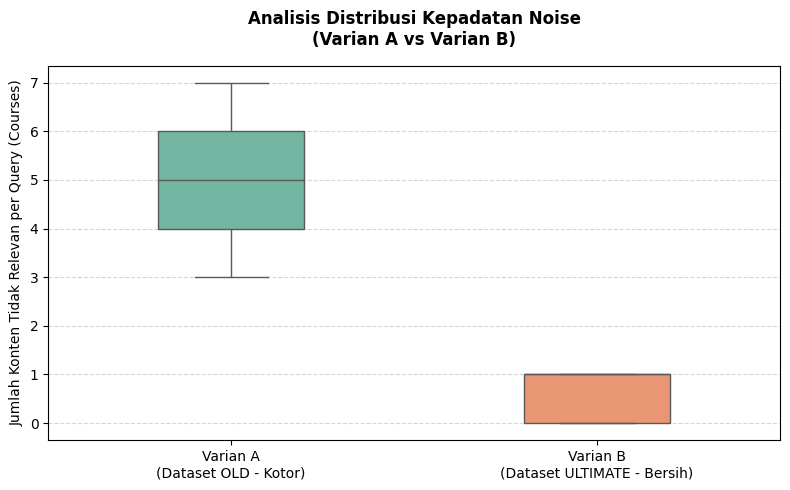

In [20]:
# Setup ukuran grafik tunggal yang lega
plt.figure(figsize=(8, 5))

# Membuat Box Plot untuk metrik Noise
sns.boxplot(data=df[['noise_variant_a', 'noise_variant_b']], palette="Set2", width=0.4)

# Estetika Grafik
plt.title('Analisis Distribusi Kepadatan Noise\n(Varian A vs Varian B)', fontsize=12, fontweight='bold', pad=15)
plt.xticks([0, 1], ['Varian A\n(Dataset OLD - Kotor)', 'Varian B\n(Dataset ULTIMATE - Bersih)'], fontsize=10)
plt.ylabel('Jumlah Konten Tidak Relevan per Query (Courses)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Visualisasi 2: Boxplot Perbandingan Kecepatan Latency

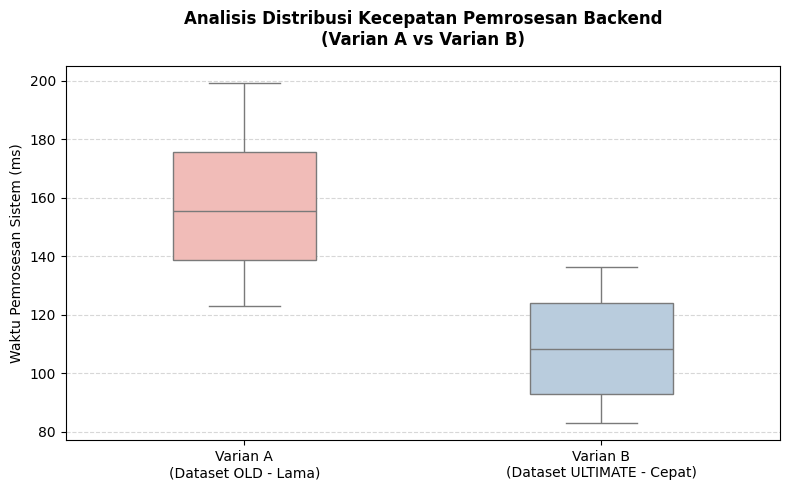

In [21]:
# Setup ukuran grafik tunggal yang lega
plt.figure(figsize=(8, 5))

# Membuat Box Plot untuk metrik Latency
sns.boxplot(data=df[['latency_variant_a', 'latency_variant_b']], palette="Pastel1", width=0.4)

# Estetika Grafik
plt.title('Analisis Distribusi Kecepatan Pemrosesan Backend\n(Varian A vs Varian B)', fontsize=12, fontweight='bold', pad=15)
plt.xticks([0, 1], ['Varian A\n(Dataset OLD - Lama)', 'Varian B\n(Dataset ULTIMATE - Cepat)'], fontsize=10)
plt.ylabel('Waktu Pemrosesan Sistem (ms)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Visualisasi 3: Bar Chart Perbandingan Rata-rata Kemunculan Noise per Query

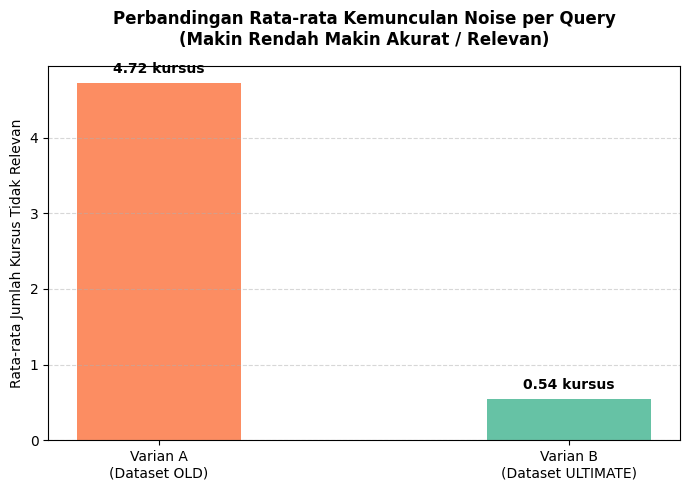

In [18]:
# Hitung rata-rata eksak dari dataframe
mean_noise_a = df['noise_variant_a'].mean()
mean_noise_b = df['noise_variant_b'].mean()

# Setup ukuran grafik tunggal yang lega
plt.figure(figsize=(7, 5))

# Membuat Bar Chart untuk Noise
bars_noise = plt.bar(['Varian A\n(Dataset OLD)', 'Varian B\n(Dataset ULTIMATE)'], 
                     [mean_noise_a, mean_noise_b], 
                     color=['#fc8d62', '#66c2a5'], 
                     width=0.4)

# Estetika Grafik
plt.title('Perbandingan Rata-rata Kemunculan Noise per Query\n(Makin Rendah Makin Akurat / Relevan)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Rata-rata Jumlah Kursus Tidak Relevan', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan Label Angka Eksak di Atas Batang Grafik
for bar in bars_noise:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f} kursus", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Visualisasi 4: Bar Chart Perbandingan Rata-rata Latency Backend

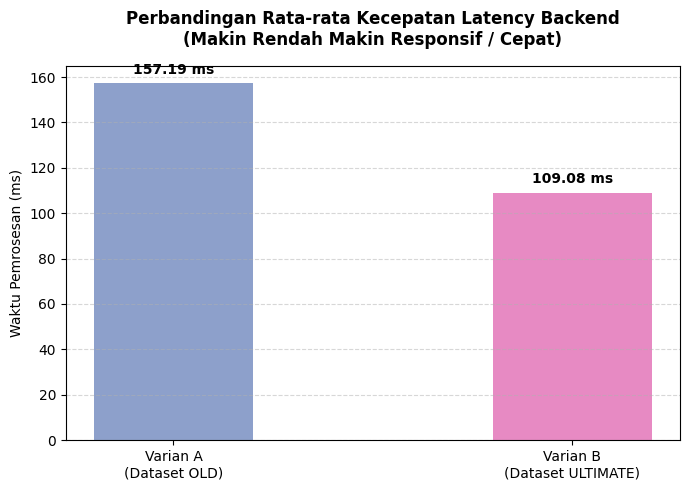

In [19]:
# Hitung rata-rata eksak dari dataframe
mean_latency_a = df['latency_variant_a'].mean()
mean_latency_b = df['latency_variant_b'].mean()

# Setup ukuran grafik tunggal yang lega
plt.figure(figsize=(7, 5))

# Membuat Bar Chart untuk Latency
bars_lat = plt.bar(['Varian A\n(Dataset OLD)', 'Varian B\n(Dataset ULTIMATE)'], 
                   [mean_latency_a, mean_latency_b], 
                   color=['#8da0cb', '#e78ac3'], 
                   width=0.4)

# Estetika Grafik
plt.title('Perbandingan Rata-rata Kecepatan Latency Backend\n(Makin Rendah Makin Responsif / Cepat)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Waktu Pemrosesan (ms)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan Label Angka Eksak di Atas Batang Grafik
for bar in bars_lat:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, f"{yval:.2f} ms", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()